# Library Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import locomotion_helper_functions as lf
from pathlib import Path
import pandas as pd
import pingouin as pg
import seaborn as sns
from statsmodels.formula.api import ols
from scipy import stats
from statannotations.Annotator import Annotator

# Plot Theme Setup

In [57]:
sns.set_theme(font_scale=1.5)
sns.set_palette("pastel")
sns.set_style(style="white")
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['lines.linewidth'] = 0.5  # For the actual data lines
plt.rcParams['axes.linewidth'] = 0.5   # For the plot border/spines
plt.rcParams['xtick.major.width'] = 0.5 # For the tick marks
plt.rcParams['ytick.major.width'] = 0.5

In [ ]:
# map specific groups to specific colors
color_map = {
    'Het': '#76DEC6', 
    'KO': '#B1DE76', 
    'WT': '#DFB473', 
    'female': '#9273DE',
    'F': '#9273DE',
    'male': '#CC638B',
    'M': '#CC638B'
}

In [ ]:
# for ordering cateories in plots
maternal_genotype_order = ["WT, "Het"]
genotype_order = ["WT", "Het", "KO"]
sex_order = ["male", "female"]

In [ ]:
# map keypoint names for titles
part_map = {
    "nose": "Nose",
    "head_midpoint": "Head",
    "mouse_center": "Body Center",
    "left_shoulder": "Left Shoulder",
    "right_shoulder": "Right Shoulder", 
    "left_hip": "Left Hip",
    "right_hip": "Right Hip"
}

# Directory Setup

Assumes the following file structure:

- DLC/
  - Projects/
  - Results/
  - p14_oxtrko/
    - pose_estimation/
    - locomotion/
  - Scripts/ (you are here)
  - Videos/
    - p14_isolation_cropped/

In [6]:
base_path = Path.cwd()
dlc_dir = lf.find_parent_dir(base_path, "DLC")
scripts_dir = dlc_dir.joinpath("Scripts")
results_dir = dlc_dir.joinpath("Results", "p14_oxtrko")
pose_dir = results_dir.joinpath("pose_estimation")
video_dir = dlc_dir.joinpath("Videos", "p14_isolation_cropped")
locomotion_dir = results_dir.joinpath("locomotion")
print(dlc_dir)
print(scripts_dir) 
print(pose_dir)
print(video_dir)

/Users/gracehickey/Documents/Research/Hammock/HTM/DLC
/Users/gracehickey/Documents/Research/Hammock/HTM/DLC/Scripts
/Users/gracehickey/Documents/Research/Hammock/HTM/DLC/Results/p14_oxtrko/pose_estimation
/Users/gracehickey/Documents/Research/Hammock/HTM/DLC/Videos/p14_isolation_cropped


In [ ]:
plot_export_location = "" # location for plots to export to

# Files, Subjects, and Video Lists

In [ ]:
# Create a list of csv files in the pose estimation directory, the names of those subjects, and their videos
subject_list_path = results_dir.joinpath("subject_list.csv")

# p14 oxtrkos: col 0 = id, 1 = genotype, 2 = sex
subj_df = pd.read_csv(subject_list_path) #.set_index(["genotype", "sex", "dam", "sire", "maternal_genotype", "paternal_genotype", "litter"])    # import subject list dataframe
subj_df = subj_df[subj_df["subject"]!= "20231222_6"] # removed because pose estimation file is weirdly short (only 60k frames)
subjects = subj_df["subject"].values.tolist()

# sort by sex 
M_subj = subj_df.loc[subj_df["sex"] == "M", "subject"].tolist() # make male list 
F_subj = subj_df.loc[subj_df["sex"] == "F", "subject"].tolist() # make female list

# sort by genotype 
WT_subj = subj_df.loc[subj_df["genotype"] == "WT", "subject"].tolist() # make wildtype list
het_subj = subj_df.loc[subj_df["genotype"] == "Het", "subject"].tolist() # make het list
KO_subj = subj_df.loc[subj_df["genotype"] == "KO", "subject"].tolist() # make knockout list

videos = [video_dir.joinpath(f"p14_isolation_{name}.mp4") for name in subjects]
# print(videos)

bodyparts = ["nose", "head_midpoint", "mouse_center", "tail_base", "tail3", "tail_end", "left_shoulder", "right_shoulder", "left_midside", "right_midside", "left_hip", "right_hip"] # leave out centroid

In [ ]:
# read in dataframes if already calculated
total_dist_df = pd.read_csv(f"{locomotion_dir}/total_distance.csv").set_index(['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter'])
log_total_dist_df = pd.read_csv(f"{locomotion_dir}/log_total_dist.csv").set_index(['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter'])
all_fivemin = pd.read_csv(f"{locomotion_dir}/five_minute_movement/all_fivemin.csv").set_index(['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter', 'minute'])
all_twentymin = pd.read_csv(f"{locomotion_dir}/twenty_minute_movement/all_twentymin.csv").set_index(['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter', 'minute'])
log_fivemin_dist_df = pd.read_csv(f"{locomotion_dir}/five_minute_movement/log_fivemin_dist.csv").set_index(['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter', 'minute'])
grouped_fivemin_avgs = pd.read_csv(f"{locomotion_dir}/five_minute_movement/grouped_fivemin.csv").set_index(['litter', 'subject', 'sex', 'genotype', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'minute'])
grouped_twentymin_avgs = pd.read_csv(f"{locomotion_dir}/twenty_minute_movement/grouped_twentymin.csv").set_index(['litter', 'subject', 'sex', 'genotype', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'minute'])

## Averaging for litter effects

In [14]:
# averaging for each group in each litter (sex and genotype) - total distance
averaged_total_dist = []
litters = list(set(subj_df["litter"]))
grouped_avgs = total_dist_df.reset_index().groupby(['litter', 'sex', 'genotype', 'bodypart']).agg(
    total_distance=('total_distance', 'mean'),
    maternal_genotype=('maternal_genotype', 'first'),
    paternal_genotype=('paternal_genotype', 'first')
).reset_index().set_index(['litter', 'sex', 'genotype', 'bodypart', 'maternal_genotype', 'paternal_genotype'])
log_grouped_avgs = grouped_avgs.copy()
log_grouped_avgs["total_distance"] = np.log10(grouped_avgs["total_distance"])
bc_grouped_avgs = grouped_avgs.copy()
# print(log_grouped_avgs["total_distance"])
bc_grouped_avgs["total_distance"], boxcox_lambda = stats.boxcox(grouped_avgs["total_distance"]) # log transform

In [ ]:
# averaging for litter effects - five minute bins
grouped_fivemin_avgs = all_fivemin.reset_index().groupby(['litter', 'sex', 'genotype', 'bodypart', 'minute']).agg(
    distance=('distance', 'mean'),
    maternal_genotype=('maternal_genotype', 'first'),
    paternal_genotype=('paternal_genotype', 'first')
    ).reset_index().set_index(['litter', 'sex', 'genotype', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'minute'])

In [ ]:
# averaging for litter effects - twenty minute bins
grouped_twentymin_avgs = all_twentymin.reset_index().groupby(['litter', 'sex', 'genotype', 'bodypart', 'minute']).agg(
    distance=('distance', 'mean'),
    maternal_genotype=('maternal_genotype', 'first'),
    paternal_genotype=('paternal_genotype', 'first')
    ).reset_index().set_index(['litter', 'sex', 'genotype', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'minute'])

In [ ]:
grouped_fivemin_avgs.to_csv(f'{locomotion_dir}/five_minute_movement/grouped_fivemin_2.csv', index=False)
grouped_twentymin_avgs.to_csv(f'{locomotion_dir}/twenty_minute_movement/grouped_twentymin_2.csv', index=False)

# Binning
Only run once; output is saved to a csv

## 5 minute binning

In [ ]:
# do binning (only need to run once)
# subjects = ["20231220_1", "20231220_2"] # shorten subject list for testing

for i, ind in enumerate(subjects):
    sec_dist_path = locomotion_dir.joinpath("second_movement_centroids", f"{ind}_sec_dists.csv")
    # read in the distance array and tell it index columns are 0, 1, 2 (name, bodypart, minute/second)
    df = pd.read_csv(sec_dist_path, usecols=["bodypart", "second", "distance"], index_col=["bodypart", "second"])
    dfs = []

    export_path = Path(f"{locomotion_dir}/five_minute_movement_centroids/{ind}_fivemins.csv")
    if export_path.is_file():
        print(f"{ind}'s five minute spreadsheet has already been created.")
        continue
    
    for part in bodyparts:
        # read in sec_dists from csv for each bodypart
        sec_dists = df.xs(
            (part),
            level=("bodypart")
        )["distance"].to_numpy()

        # use binned_dist function to bin data in 5 minute chunks
        fivemin_dists = lf.binned_dist(sec_dists, 5, 'm')
        m = len(fivemin_dists)
        df_loop = pd.DataFrame(
            {"distance": fivemin_dists},
            index=pd.MultiIndex.from_arrays(
                [
                    np.repeat(ind, m),
                    np.repeat(part, m),
                    np.arange(start=5, stop=(m+1)*5, step=5)
                ],
                names=["name", "bodypart", "minute"]
            )
        )
        dfs.append(df_loop)
    
    del df

    dfs_min = pd.concat(dfs)
    dfs_min.to_csv(export_path)

    del dfs

## 20 minute binning

In [ ]:
# do 20 minute binning (only need to run once) 

# subjects = [""]

for i, ind in enumerate(subjects):
    sec_dist_path = locomotion_dir.joinpath("second_movement", f"{ind}_sec_dists.csv")
    df = pd.read_csv(sec_dist_path, usecols=["bodypart", "second", "distance"], index_col=["bodypart", "second"])
    dfs = []

    export_path = Path(f"{locomotion_dir}/twenty_minute_movement/{ind}_twentymins.csv")
    if export_path.is_file():
        print(f"{ind}'s twenty minute spreadsheet has already been created.")
        continue
    
    for part in bodyparts:
        # read in sec_dists from csv for each bodypart
        sec_dists = df.xs(
            (ind, part),
            level=("name", "bodypart")
        )["distance"].to_numpy()

        # use binned_dist function to bin data in 20 minute chunks
        fivemin_dists = lf.binned_dist(sec_dists, 20, 'm')
        m = len(fivemin_dists)
        df_loop = pd.DataFrame(
            {"distance": fivemin_dists},
            index=pd.MultiIndex.from_arrays(
                [
                    np.repeat(ind, m),
                    np.repeat(part, m),
                    np.arange(start=20, stop=(m+1)*20, step=20)
                ],
                names=["name", "bodypart", "minute"]
            )
        )
        dfs.append(df_loop)
    
    del df

    dfs_min = pd.concat(dfs)
    dfs_min.to_csv(export_path)

    del dfs

# Create long-form dataframes
Only need to do once; output is saved to csv

In [11]:
# 1. Five minute dataframe
## 1. Create a helper dictionary for fast genotype lookup: {subject_id: genotype}
genotype_map = subj_df.set_index('subject')['genotype'].to_dict()

all_data = []


for row in subj_df.itertuples():
    five_min_path = Path(f"{locomotion_dir}/five_minute_movement/{row.subject}_fivemins.csv")

    df = pd.read_csv(five_min_path, usecols=["bodypart", "minute", "distance"])
    df = df[df['minute'].isin(range(5, 90, 5))]

    df['subject'] = row.subject
    df['sex'] = row.sex
    df['genotype'] = row.genotype
    df['maternal_genotype'] = row.maternal_genotype
    df['paternal_genotype'] = row.paternal_genotype
    df['dam'] = row.dam
    df['sire'] = row.sire
    df['litter'] = row.litter

    all_data.append(df)


# 2. Combine everything vertically
all_fivemin = pd.concat(all_data, ignore_index=True)
all_fivemin.to_csv(f'{locomotion_dir}/five_minute_movement/all_fivemin.csv', index=False)

# 3. Set the MultiIndex 
all_fivemin = all_fivemin.set_index(['genotype', 'sex', 'subject', 'bodypart', 'minute', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter']).sort_index()

In [ ]:
# 1. Twenty minute dataframe
## 1. Create a helper dictionary for fast genotype lookup: {subject_id: genotype}
genotype_map = subj_df.set_index('subject')['genotype'].to_dict()

all_data = []


for row in subj_df.itertuples():
    twenty_min_path = Path(f"{locomotion_dir}/twenty_minute_movement/{row.subject}_twentymins.csv")

    df = pd.read_csv(twenty_min_path, usecols=["bodypart", "minute", "distance"])
    df = df[df['minute'].isin(range(20, 90, 20))]

    df['subject'] = row.subject
    df['sex'] = row.sex
    df['genotype'] = row.genotype
    df['maternal_genotype'] = row.maternal_genotype
    df['paternal_genotype'] = row.paternal_genotype
    df['dam'] = row.dam
    df['sire'] = row.sire
    df['litter'] = row.litter

    all_data.append(df)


# 2. Combine everything vertically
all_twentymin = pd.concat(all_data, ignore_index=True)
all_twentymin.to_csv(f'{locomotion_dir}/twenty_minute_movement/all_twentymin.csv', index=False)


# 3. Set the MultiIndex 
all_twentymin = all_twentymin.set_index(['genotype', 'sex', 'subject', 'bodypart', 'minute', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter']).sort_index()

In [22]:
# Summing distance while keeping genotype, sex, subject, and bodypart
total_dist_df = all_fivemin.groupby(level=['genotype', 'sex', 'subject', 'bodypart', 'maternal_genotype', 'paternal_genotype', 'dam', 'sire', 'litter']).sum()

# Rename the 'distance' column to 'total_distance' for clarity
total_dist_df = total_dist_df.rename(columns={'distance': 'total_distance'})

In [23]:
total_dist_df.reset_index().to_csv(f'{locomotion_dir}/total_distance.csv', index=False)

# Assessing normality

## pre-transformation

nose
          W      pval  normal
0  0.950497  0.062151    True
               W      pval  equal_var
levene  0.645736  0.776017       True
head_midpoint
          W      pval  normal
0  0.963508  0.186082    True
               W      pval  equal_var
levene  0.878883  0.569309       True
mouse_center
          W      pval  normal
0  0.869465  0.000168   False
               W     pval  equal_var
levene  0.343544  0.96805       True


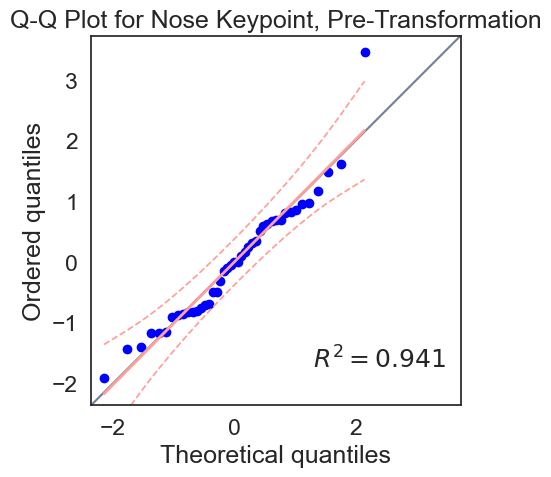

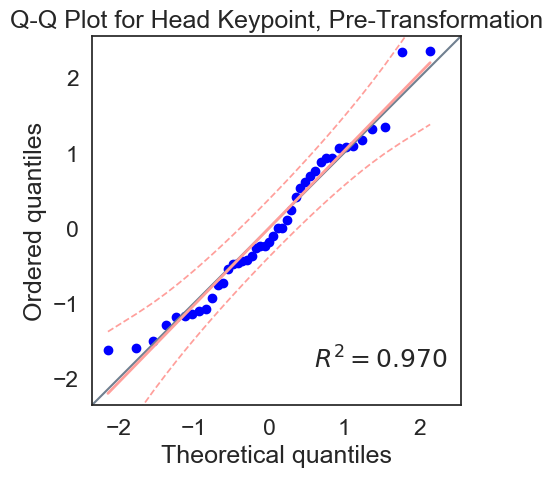

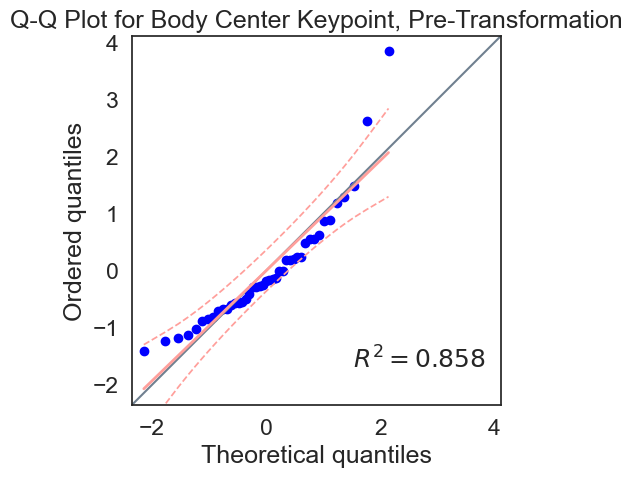

<Figure size 640x480 with 0 Axes>

In [28]:
# 1. Fit the Two-Way ANOVA model
# Formula: 'dv ~ factor1 * factor2' includes main effects AND interaction
for part in ["nose", "head_midpoint", "mouse_center"]:
    print(part)
    data = grouped_avgs.xs(part, level="bodypart").reset_index()
    data['interaction_group'] = data['genotype'] + "_" + data['sex'] + '_' + data['maternal_genotype']
    model = ols('total_distance ~ C(genotype) * C(sex) * C(maternal_genotype)', data=data).fit()

    # 2. Extract residuals
    residuals = model.resid
    data["residuals"] = residuals
    # Normality check with Pingouin
    normality_results = pg.normality(residuals)
    print(normality_results)

    # Visual check
    pg.qqplot(residuals, dist='norm')
    plt.title(f"Q-Q Plot for {part_map[part]} Keypoint, Pre-Transformation")
    plt.savefig(f"{plot_export_location}/qq/qq_grouped_{part}.svg", format="svg")
    plt.figure()

    homogeneity = pg.homoscedasticity(data=data, dv='residuals', group="interaction_group")
    print(homogeneity)

## transformations

In [21]:
log_total_dist_df = total_dist_df.copy()
log_total_dist_df["total_distance"] = np.log10(total_dist_df["total_distance"])

In [23]:
log_fivemin_dist_df = all_fivemin.copy()
log_fivemin_dist_df["distance"] = np.log10(all_fivemin["distance"]+1)

In [88]:
log_grouped_fivemin = grouped_fivemin_avgs.copy()
log_grouped_fivemin["distance"] = np.log10(grouped_fivemin_avgs["distance"]+1)

In [95]:
log_twentymin_dist_df = all_twentymin.copy()
log_twentymin_dist_df["distance"] = np.log10(all_twentymin["distance"]+1)

In [89]:
log_grouped_twentymin = grouped_twentymin_avgs.copy()
log_grouped_twentymin["distance"] = np.log10(grouped_twentymin_avgs["distance"]+1)

In [ ]:
# write to CSVs
log_total_dist_df.reset_index().to_csv(f'{locomotion_dir}/log_total_dist.csv', index=False)
log_fivemin_dist_df.reset_index().to_csv(f'{locomotion_dir}/five_minute_movement/log_fivemin_dist.csv', index=False)
log_twentymin_dist_df.reset_index().to_csv(f'{locomotion_dir}/twenty_minute_movement/log_twentymin_dist.csv', index=False)

## normality post-transformation

nose
          W      pval  normal
0  0.977018  0.533822    True
               W      pval  equal_var
levene  0.973951  0.489218       True
head_midpoint
          W      pval  normal
0  0.986925  0.899191    True
               W     pval  equal_var
levene  1.842038  0.08902       True
mouse_center
          W      pval  normal
0  0.976538  0.516421    True
               W      pval  equal_var
levene  0.504967  0.885214       True


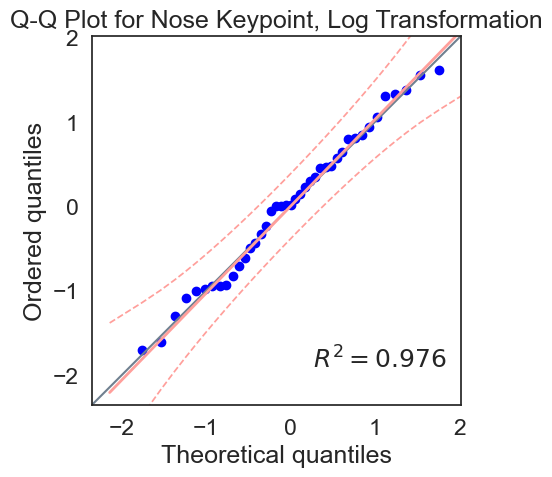

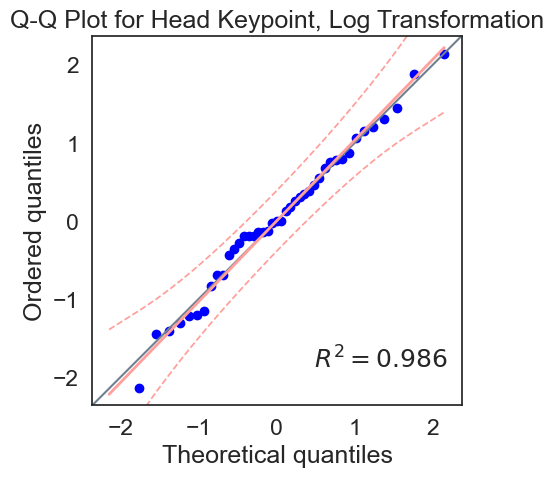

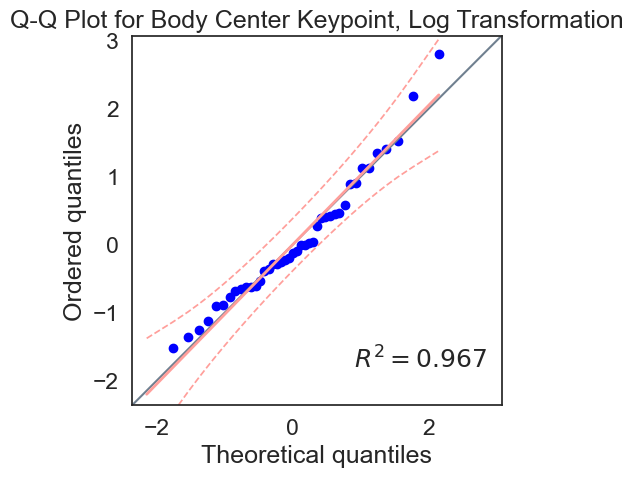

<Figure size 640x480 with 0 Axes>

In [35]:
# for total distance 
# 1. Fit the Two-Way ANOVA model
# Formula: 'dv ~ factor1 * factor2' includes main effects AND interaction
for part in ["nose", "head_midpoint", "mouse_center"]:
    print(part)
    data = log_grouped_avgs.xs(part, level="bodypart").reset_index()
    data['interaction_group'] = data['genotype'] + "_" + data['sex'] + '_' + data['maternal_genotype']
    model = ols('total_distance ~ C(genotype) * C(sex) * C(maternal_genotype)', data=data).fit()

    # 2. Extract residuals
    residuals = model.resid
    data["residuals"] = residuals
    # Normality check with Pingouin
    normality_results = pg.normality(residuals)
    print(normality_results)

    # Visual check
    # plt.figure(figsize=(2,1.5))
    pg.qqplot(residuals, dist='norm')
    plt.title(f"Q-Q Plot for {part_map[part]} Keypoint, Log Transformation")
    plt.savefig(f"{plot_export_location}/qq/qq_log_{part}.png", format="png", bbox_inches="tight")
    plt.figure()

    homogeneity = pg.homoscedasticity(data=data, dv='residuals', group="interaction_group")
    print(homogeneity)

~~~~~~~~
nose
~~~~~~~~
~~~~~~~~
20
~~~~~~~~
          W      pval  normal
0  0.989744  0.963291    True
               W      pval  equal_var
levene  0.796085  0.642673       True
~~~~~~~~
40
~~~~~~~~
         W      pval  normal
0  0.96836  0.277299    True
               W      pval  equal_var
levene  0.978649  0.485417       True
~~~~~~~~
60
~~~~~~~~
          W      pval  normal
0  0.905228  0.001809   False
               W      pval  equal_var
levene  0.490377  0.894868       True
~~~~~~~~
80
~~~~~~~~
          W      pval  normal
0  0.885654  0.000472   False
               W      pval  equal_var
levene  0.460311  0.913512       True
~~~~~~~~
head_midpoint
~~~~~~~~
~~~~~~~~
20
~~~~~~~~
          W      pval  normal
0  0.977083  0.536196    True
               W    pval  equal_var
levene  1.325178  0.2575       True
~~~~~~~~
40
~~~~~~~~
          W      pval  normal
0  0.990035  0.967923    True
               W      pval  equal_var
levene  1.293149  0.274092       True
~~~~~~~~


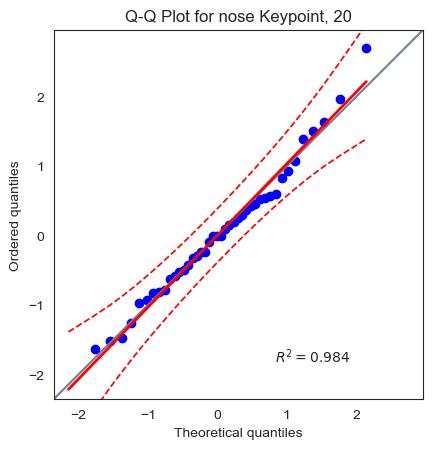

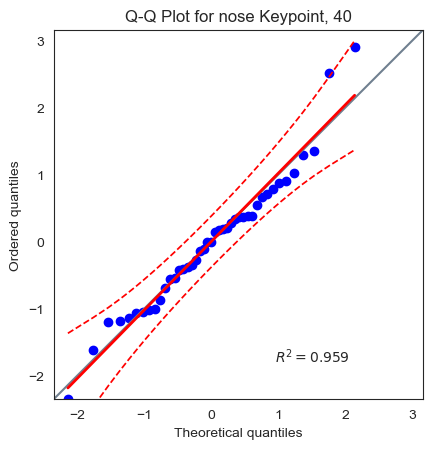

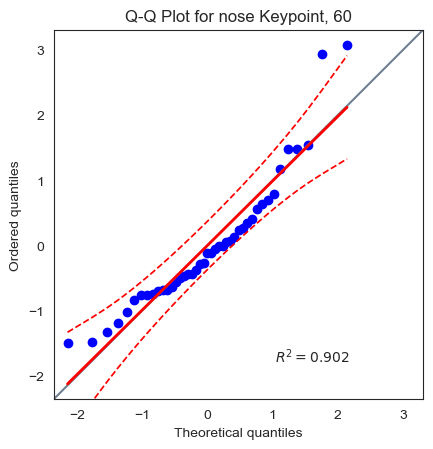

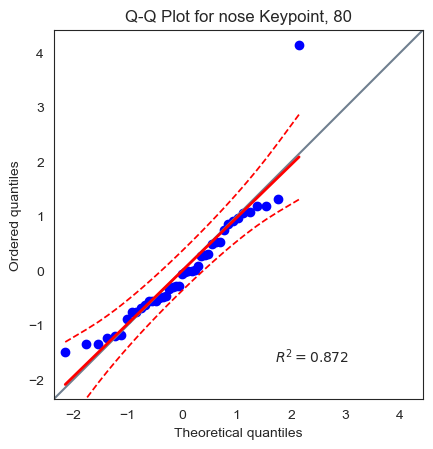

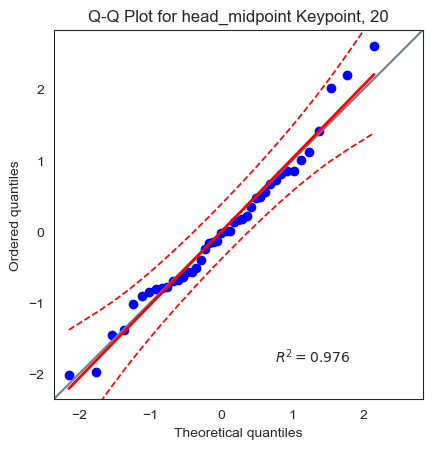

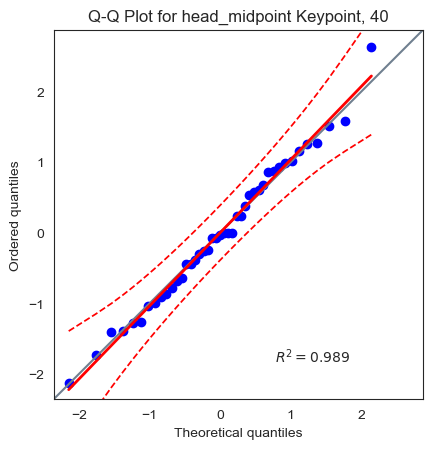

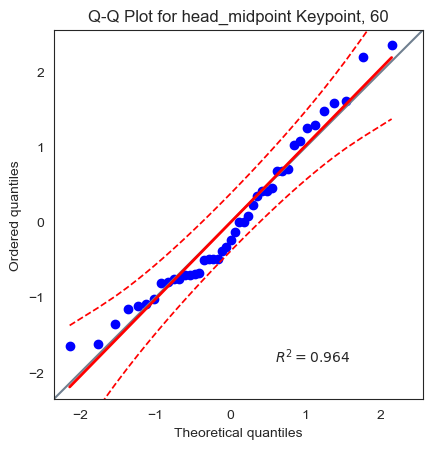

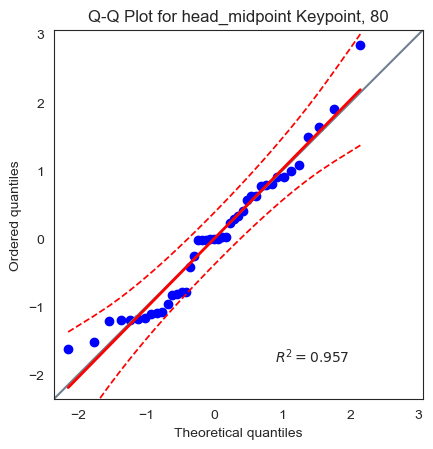

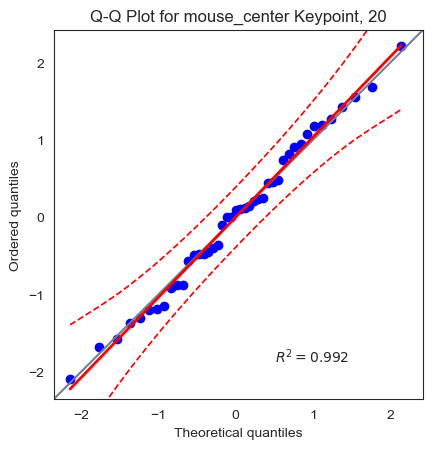

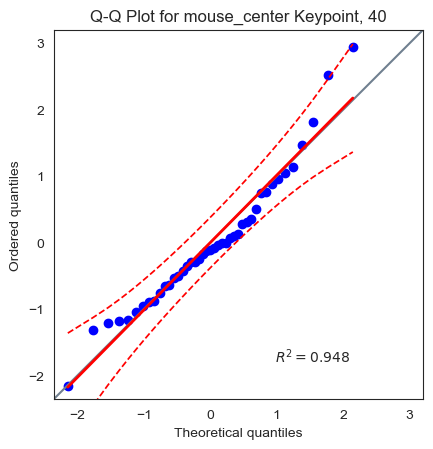

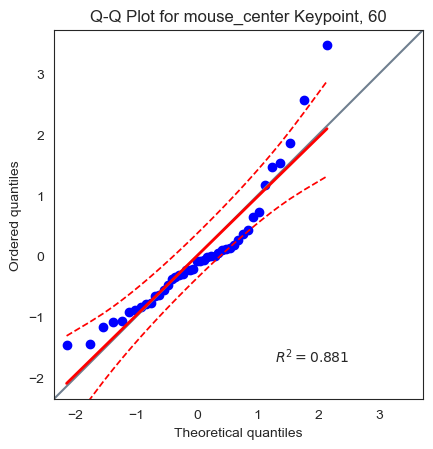

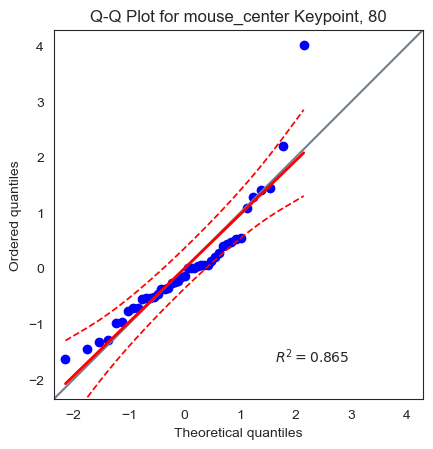

<Figure size 640x480 with 0 Axes>

In [29]:
# for twenty minute binned distance
for part in ["nose", "head_midpoint", "mouse_center"]:
    print("~~~~~~~~")
    print(part)
    print("~~~~~~~~")
    for minute in range(20,90,20):
        print("~~~~~~~~")
        print(minute)
        print("~~~~~~~~")
        data = grouped_twentymin_avgs.xs(minute, level="minute").xs(part, level="bodypart").reset_index()
        data['interaction_group'] = data['genotype'] + "_" + data['sex'] + '_' + data['maternal_genotype']
        model = ols('distance ~ C(genotype) * C(sex) * C(maternal_genotype)', data=data).fit()

        # 2. Extract residuals
        residuals = model.resid
        data["residuals"] = residuals
        # Normality check with Pingouin
        normality_results = pg.normality(residuals)
        print(normality_results)

        # Visual check
        pg.qqplot(residuals, dist='norm')
        plt.title(f"Q-Q Plot for {part} Keypoint, {minute}")
        # plt.savefig(f"{plot_export_location}/qq_log_{part}.svg", format="svg")
        plt.figure()

        homogeneity = pg.homoscedasticity(data=data, dv='residuals', group="interaction_group")
        print(homogeneity)

# Statistics

## Total Distance

### Sex * Genotype * Maternal Genotype

In [ ]:
for part in bodyparts:
    print("~~~~~~~~~~")
    print(f"Bodypart: {part}")
    print("~~~~~~~~~~")
    data = log_grouped_avgs.xs(part, level="bodypart").reset_index()
    aov = pg.anova(data=data, dv='total_distance', between=['genotype', 'sex', 'maternal_genotype'])
    print(aov)

~~~~~~~~~~
Bodypart: nose
~~~~~~~~~~
                               Source        SS    DF        MS         F  \
0                            genotype  0.032797   2.0  0.016399  0.231804   
1                                 sex  0.003878   1.0  0.003878  0.054815   
2                   maternal_genotype  0.394295   1.0  0.394295  5.573575   
3                      genotype * sex  0.030204   2.0  0.015102  0.213473   
4        genotype * maternal_genotype  0.045299   2.0  0.022649  0.320159   
5             sex * maternal_genotype  0.062525   1.0  0.062525  0.883825   
6  genotype * sex * maternal_genotype  0.150499   2.0  0.075249  1.063691   
7                            Residual  2.193054  31.0  0.070744       NaN   

      p-unc       np2  
0  0.794464  0.014735  
1  0.816427  0.001765  
2  0.024702  0.152393  
3  0.808952  0.013585  
4  0.728405  0.020237  
5  0.354425  0.027720  
6  0.357442  0.064218  
7       NaN       NaN  
~~~~~~~~~~
Bodypart: head_midpoint
~~~~~~~~~~
       

In [ ]:
# post-hoc for main effect of maternal genotype for nose, head_midpoint
data = log_grouped_avgs.xs("right_shoulder", level="bodypart")
tukey = pg.pairwise_tukey(data=data.reset_index(), dv='total_distance', between='maternal_genotype')
print(tukey)
# print confidence intervals
print(pow(10, data.xs("Het", level="maternal_genotype")["total_distance"].mean()))
print(pow(10, data.xs("Het", level="maternal_genotype")["total_distance"].mean() - 1.96*data.xs("Het", level="maternal_genotype")["total_distance"].sem()), ',', pow(10, data.xs("Het", level="maternal_genotype")["total_distance"].mean() + 1.96*data.xs("Het", level="maternal_genotype")["total_distance"].sem()))

print(pow(10, data.xs("WT", level="maternal_genotype")["total_distance"].mean()))
print(pow(10, data.xs("WT", level="maternal_genotype")["total_distance"].mean() - 1.96*data.xs("WT", level="maternal_genotype")["total_distance"].sem()), ',', pow(10, data.xs("WT", level="maternal_genotype")["total_distance"].mean() + 1.96*data.xs("WT", level="maternal_genotype")["total_distance"].sem()))

# # significant_results = tukey[tukey['p-tukey'] < 0.05]
# significant_results

     A   B   mean(A)   mean(B)      diff        se         T   p-tukey  \
0  Het  WT  2.437558  2.681325 -0.243766  0.084283 -2.892232  0.006096   

     hedges  
0 -0.942687  
273.8787115192911
185.51039547907104 , 404.3414840972053
480.0921480919334
398.5728320576369 , 578.2844492175432


In [ ]:
# post-hoc for interactions nose, head_midpoint
data = log_total_dist_df.xs("head_midpoint", level="bodypart").reset_index().copy()
data["geno_sex"] = data["genotype"].astype(str) + "_" + data["sex"].astype(str)
tukey = pg.pairwise_tukey(data=data, dv='total_distance', between='geno_sex')
significant_results = tukey[tukey['p-tukey'] < 0.05]
significant_results

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,Het_F,Het_M,2.867895,2.430172,0.437723,0.149479,2.928315,0.049534,1.028828
5,Het_M,KO_F,2.430172,2.917059,-0.486887,0.136219,-3.574290,0.007848,-1.554245
6,Het_M,KO_M,2.430172,2.987183,-0.557011,0.137455,-4.052308,0.001656,-1.794810
7,Het_M,WT_F,2.430172,2.852965,-0.422793,0.137455,-3.075864,0.033508,-1.267308


## Distance over time

### mixed ANOVA for twenty minute bins

In [90]:
for part in ["nose", "head_midpoint", "left_shoulder", "right_shoulder", "mouse_center", "left_hip", "right_hip"]: 
    print(part)
    data = grouped_twentymin_avgs.xs(part, level="bodypart").reset_index()
    aov = pg.mixed_anova(data=data, dv="distance", within="minute", between="sex", subject="subject")
    print(aov)

    posthocs = pg.pairwise_tests(
        data=data, 
        dv='distance', 
        within='minute',     # The repeated measure
        between='sex',
        subject='subject',   # Your ID column
        padjust='bh'       # This is the correction
    )
    # print(posthocs)
    # Filter to only show significant results
    significant_results = posthocs[posthocs['p-corr'] < 0.05]
    print(significant_results)

nose
        Source            SS  DF1  DF2             MS          F  \
0          sex  4.332857e+04    1   41   43328.568642   0.691338   
1       minute  1.029761e+06    3  123  343253.787857  24.232683   
2  Interaction  1.784641e+05    3  123   59488.038583   4.199676   

          p-unc     p-GG-corr       np2       eps sphericity   W-spher  \
0  4.105262e-01           NaN  0.016582       NaN        NaN       NaN   
1  2.171971e-12  1.053132e-08  0.371481  0.682069      False  0.463085   
2  7.237657e-03           NaN  0.092914       NaN        NaN       NaN   

    p-spher  
0       NaN  
1  0.000008  
2       NaN  
  Contrast minute   A   B Paired Parametric         T   dof alternative  \
0   minute      -  20  40   True       True  3.121811  42.0   two-sided   
1   minute      -  20  60   True       True  5.061838  42.0   two-sided   
2   minute      -  20  80   True       True  7.325078  42.0   two-sided   
3   minute      -  40  60   True       True  2.832587  42.0   two-sid

# Plotting

## Data distributions

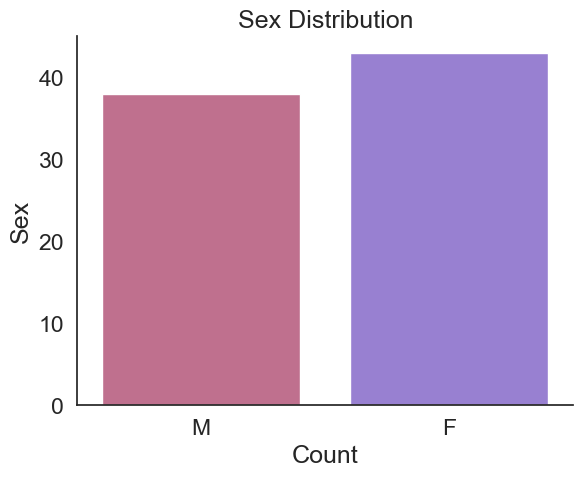

In [24]:
ax = sns.countplot(subj_df, x="sex", hue="sex", palette=color_map, order=["M", "F"])
ax.set_xlabel("Count")
ax.set_ylabel("Sex")
ax.set_title("Sex Distribution")
sns.despine()
# plt.savefig(f"{plot_export_location}/seaborn_sex_distribution.svg", format='svg')

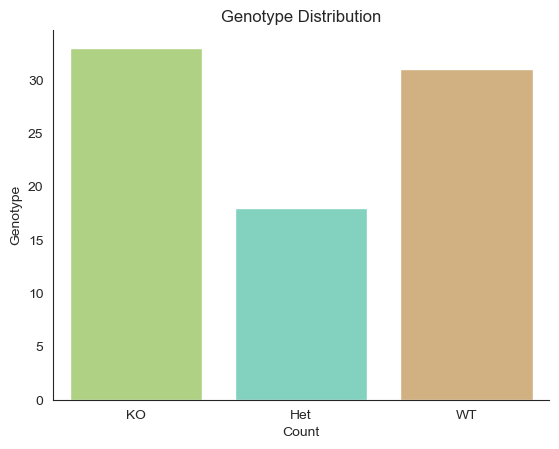

In [55]:
ax = sns.countplot(subj_df, x="genotype", hue="genotype", palette=color_map, order=genotype_order)
ax.set_xlabel("Count")
ax.set_ylabel("Genotype")
ax.set_title("Genotype Distribution")
sns.despine()
plt.savefig(f"{plot_export_location}/seaborn_genotype_distribution.svg", format="svg")

## One bodypart over time by group

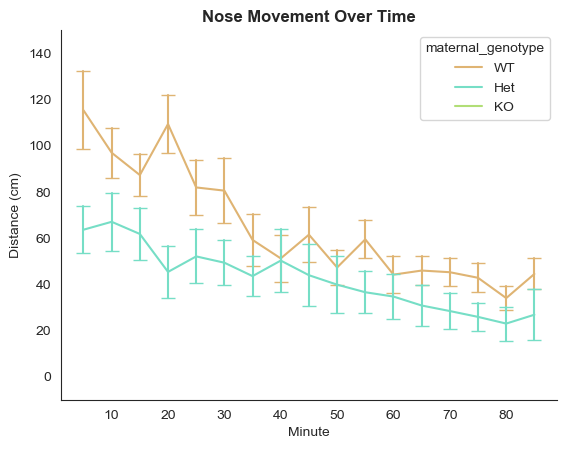

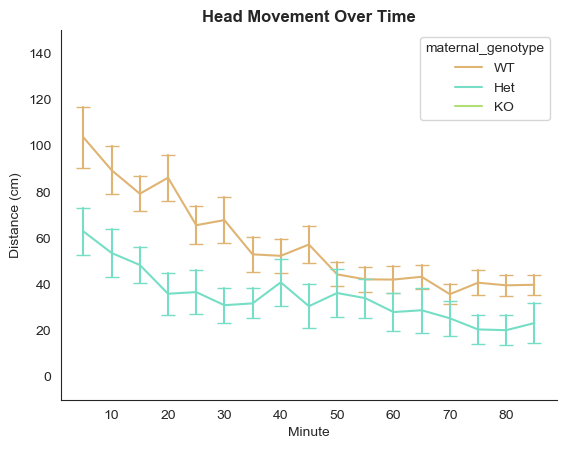

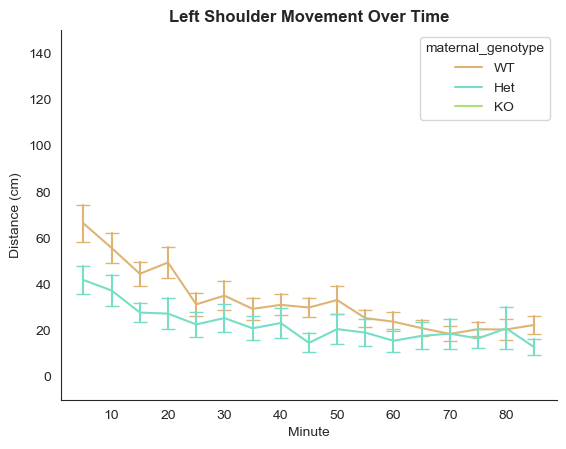

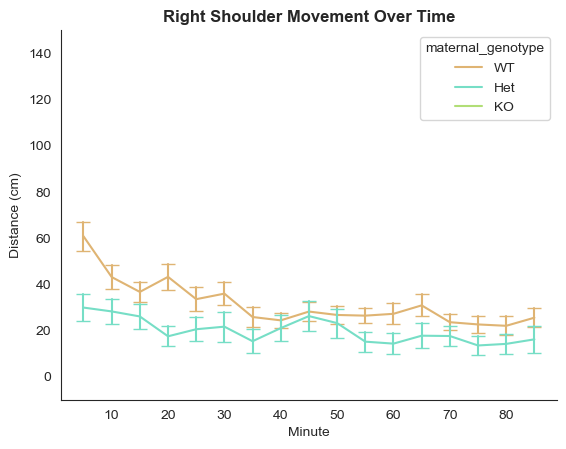

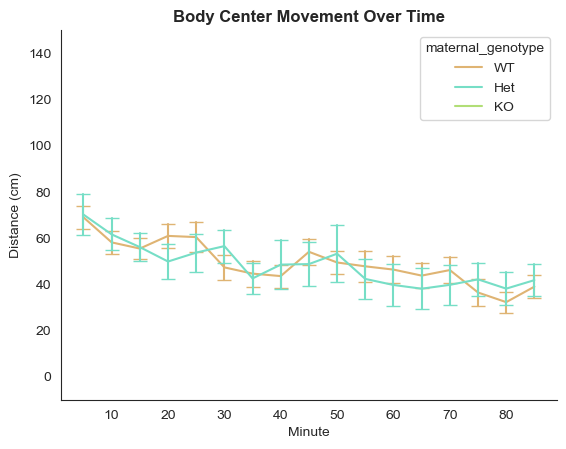

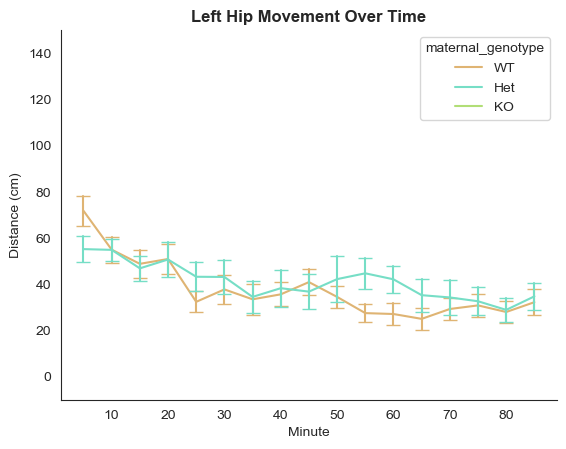

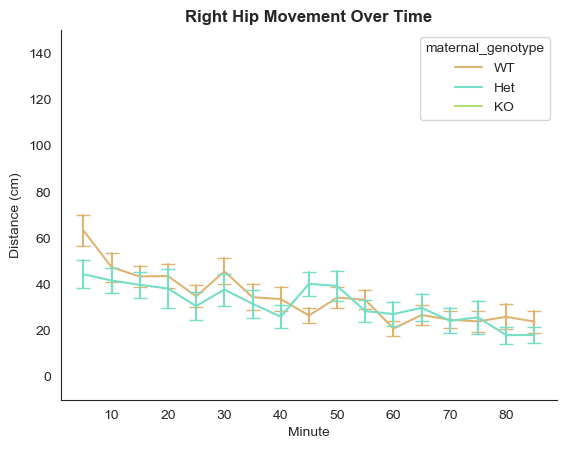

<Figure size 640x480 with 0 Axes>

In [ ]:
for part in ["nose", "head_midpoint", "left_shoulder", "right_shoulder", "mouse_center", "left_hip", "right_hip"]: 
    hue = "maternal_genotype"
    ax = sns.lineplot(data=grouped_fivemin_avgs.xs(part, level="bodypart").reset_index(), x='minute', y='distance', hue=hue, 
                errorbar='se', err_style="bars", err_kws={"capsize": 5}, alpha=1, palette=color_map, hue_order=genotype_order)
    sns.despine()
    ax.set_ylim(-10,150)
    ax.set_title(f"{part_map[part]} Movement Over Time", fontweight="semibold")
    ax.set_xlabel("Minute")
    ax.set_ylabel("Distance (cm)")
    plt.savefig(f"{plot_export_location}/fivemin/{hue}_{part}.svg", format="svg")
    plt.figure()

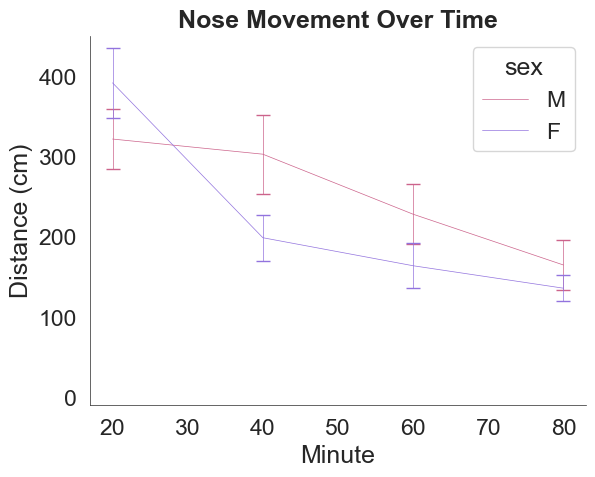

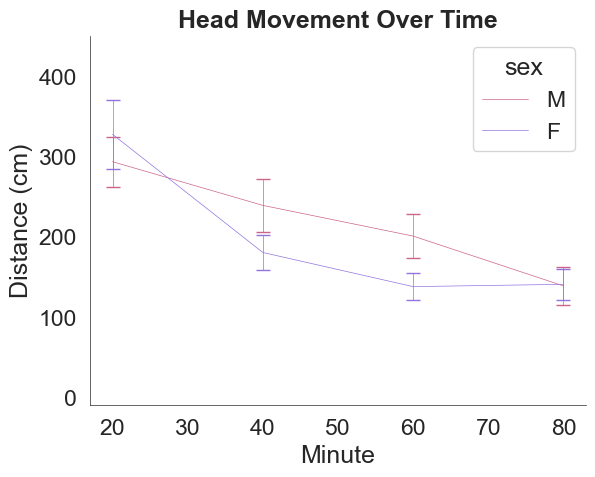

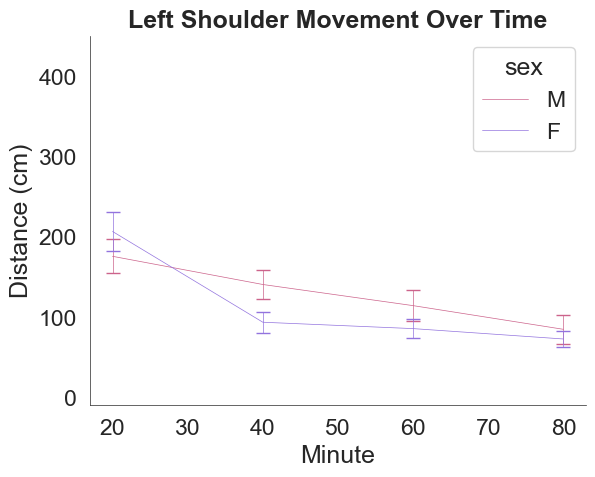

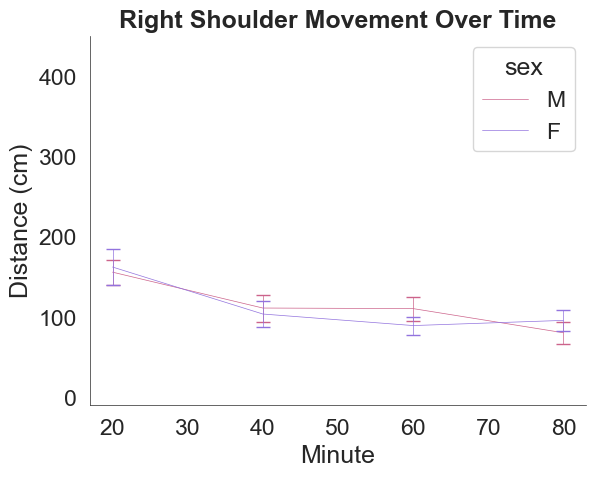

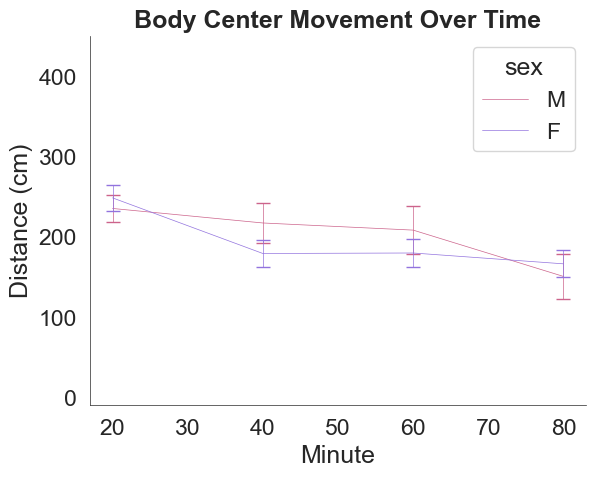

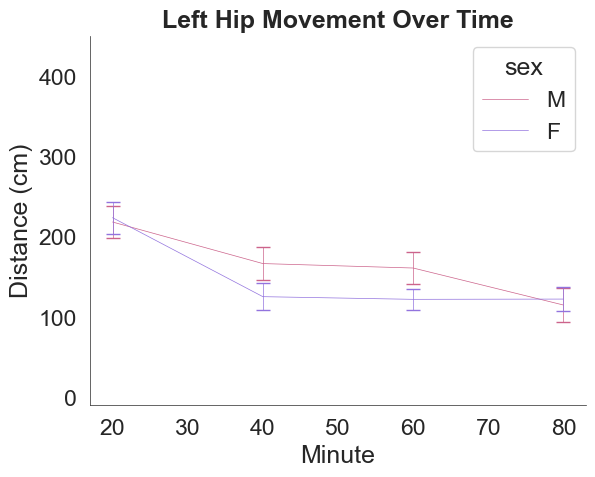

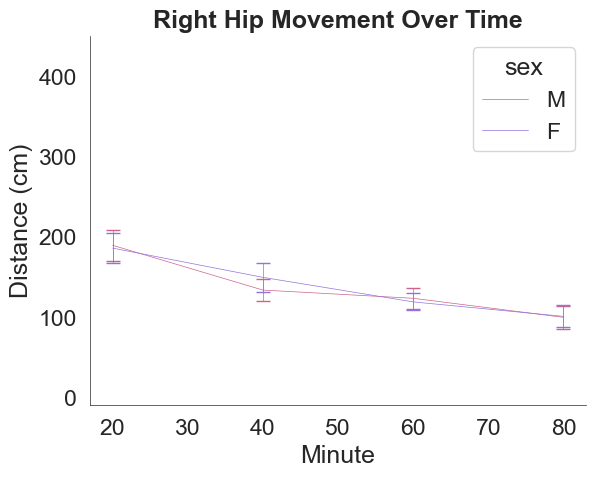

<Figure size 640x480 with 0 Axes>

In [111]:
for part in ["nose", "head_midpoint", "left_shoulder", "right_shoulder", "mouse_center", "left_hip", "right_hip"]: 
    hue = "sex"
    data=grouped_twentymin_avgs.xs(part, level="bodypart").reset_index()
    data['minute'] = data['minute'].astype(int)
    ax = sns.lineplot(data=data, x='minute', y='distance', hue=hue, 
                errorbar='se', err_style="bars", err_kws={"capsize": 5}, alpha=1, palette=color_map, hue_order=["M", "F"])
    sns.despine()
    ax.set_ylim(-10,450)
    ax.set_title(f"{part_map[part]} Movement Over Time", fontweight="semibold")
    ax.set_xlabel("Minute")
    ax.set_ylabel("Distance (cm)")



    # plt.savefig(f"{plot_export_location}/twentymin/{hue}_{part}.svg", format="svg")
    plt.figure()

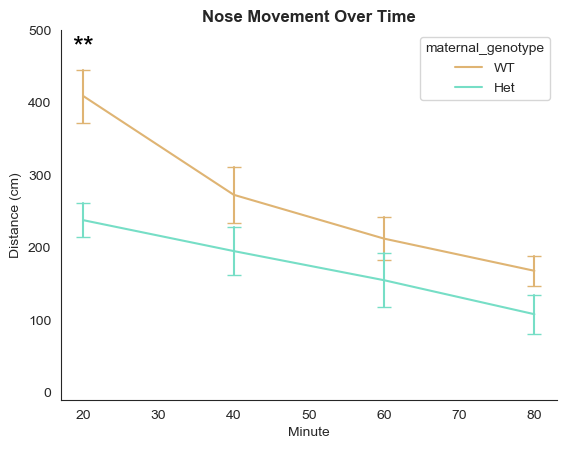

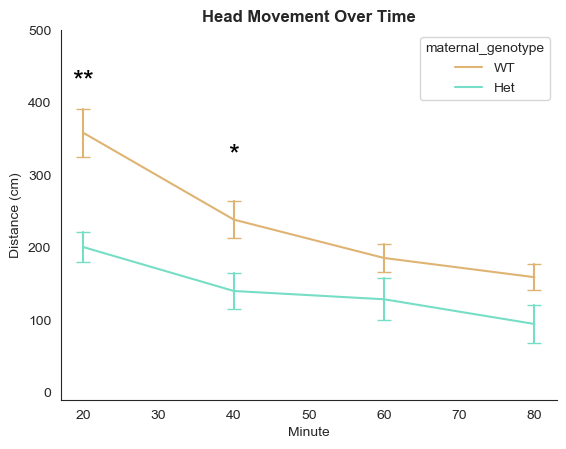

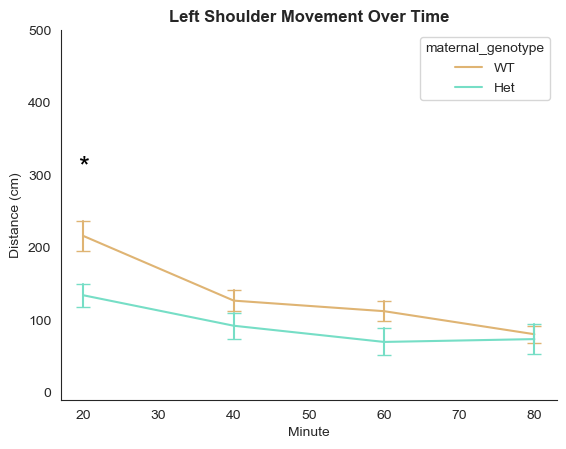

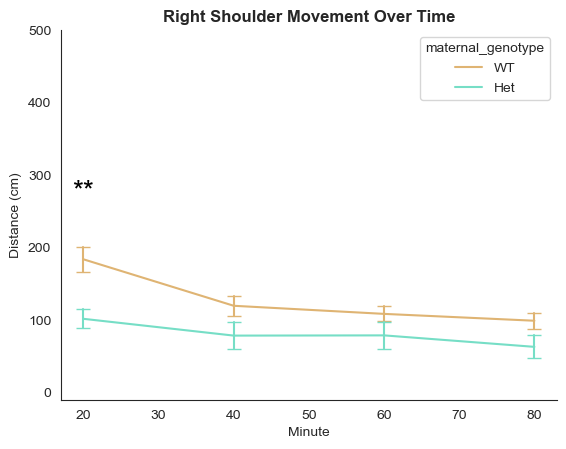

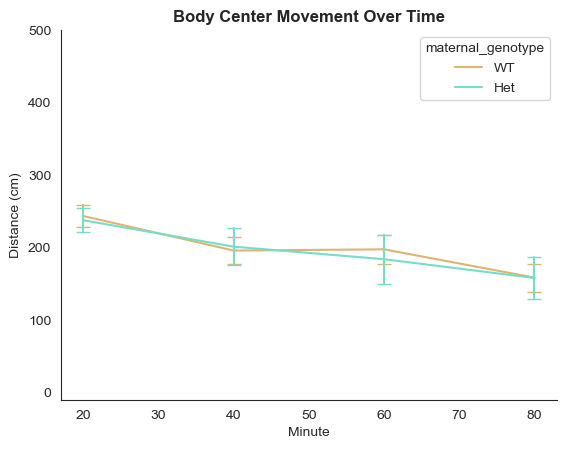

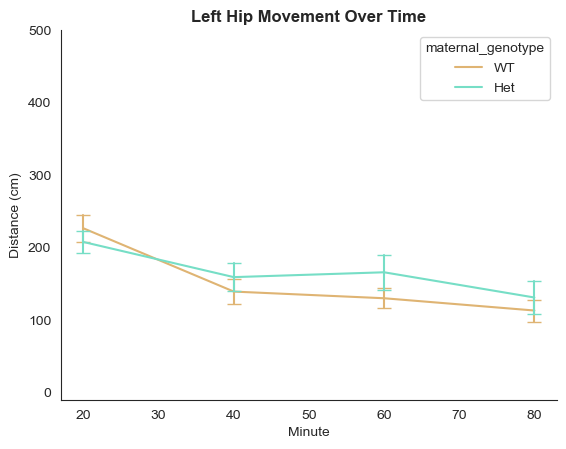

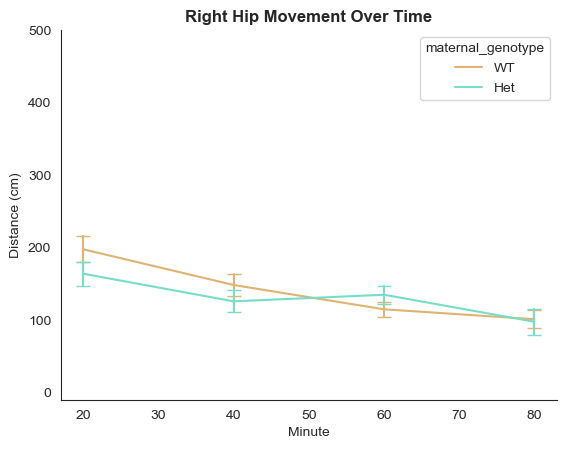

<Figure size 640x480 with 0 Axes>

In [76]:
p_dict = {
    "nose": {20: 0.0012, 40: .6, 60: .6, 80: .6},
    "head_midpoint": {20: 0.00102, 40: .0166, 60: .6, 80: .6},
    "mouse_center": {20: 0.6, 40: .6, 60: .6, 80: .6},
    "left_shoulder": {20: 0.0139, 40: .6, 60: .6, 80: .6},
    "right_shoulder": {20: 0.0016, 40: .6, 60: .6, 80: .6},
    "left_hip": {20: 0.6, 40: .6, 60: .6, 80: .6},
    "right_hip": {20: 0.6, 40: .6, 60: .6, 80: .6}
}
for part in ["nose", "head_midpoint", "left_shoulder", "right_shoulder", "mouse_center", "left_hip", "right_hip"]: 
    hue = "maternal_genotype"
    data=grouped_twentymin_avgs.xs(part, level="bodypart").reset_index()
    data['minute'] = data['minute'].astype(int)
    ax = sns.lineplot(data=data, x='minute', y='distance', hue=hue, 
                errorbar='se', err_style="bars", err_kws={"capsize": 5}, alpha=1, palette=color_map, hue_order=["WT", "Het"])
    sns.despine()
    # ax.set_ylim(-10,450)
    ax.set_title(f"{part_map[part]} Movement Over Time", fontweight="semibold")
    ax.set_xlabel("Minute")
    ax.set_ylabel("Distance (cm)")
    for m in [20,40,60,80]:
        p_val = p_dict[part][m]
        if p_val < 0.05:
            y_pos = data[data['minute']==m]['distance'].mean() + 100
            # Determine how many stars to show
            stars = "*" if p_val < 0.05 else ""
            if p_val < 0.01: stars = "**"
            if p_val < 0.001: stars = "***"

            ax.text(m, y_pos, stars, ha='center', va='bottom', color='black', fontsize=20)


    sns.despine()
    ax.set_ylim(-10, 500) # Increased slightly to make room for markers

    plt.savefig(f"{plot_export_location}/twentymin/{hue}_{part}_sig.svg", format="svg")
    plt.figure()

## All bodyparts

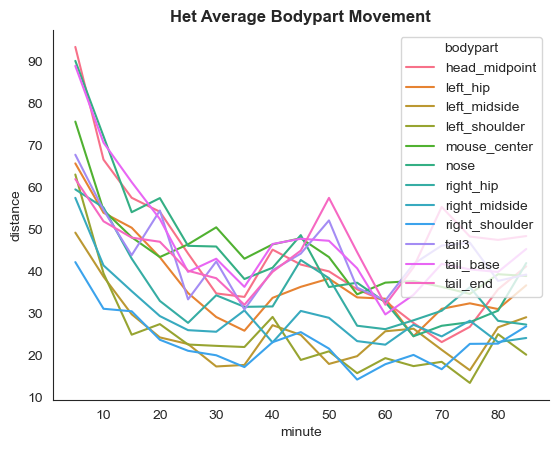

In [ ]:
# plot all bodyparts
group = "Het"
level = "genotype"
ax = sns.lineplot(data=grouped_fivemin_avgs.xs(group, level=level), x='minute', y='distance', hue='bodypart',
             errorbar=None)
sns.despine()
ax.set_title(f"{group.capitalize() if level=='sex' else group} Average Bodypart Movement", fontweight="semibold")
plt.savefig(f"{plot_export_location}/seaborn_{group}_allParts_5min.svg", format="svg")

## Total distance

### Sex

p-value annotation legend:
    n.s.: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

F vs. M: t-test independent samples, P_val:5.395e-01 t=-6.187e-01


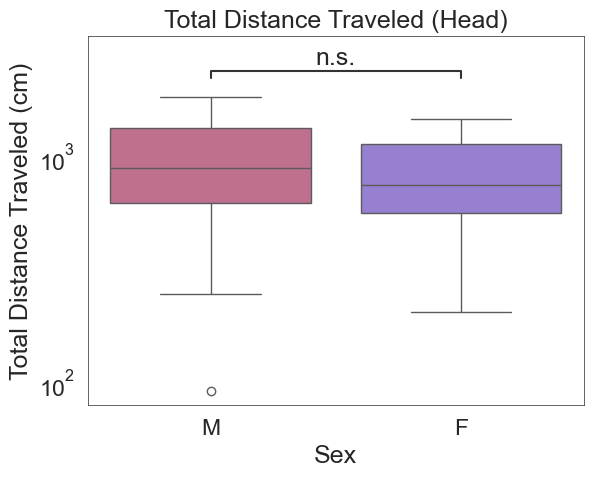

In [61]:
part = "head_midpoint"
data = grouped_avgs.xs(part, level="bodypart").reset_index()
g = sns.boxplot(data=data, x="sex", y="total_distance", hue="sex", order=["M", "F"], palette=color_map, log_scale=True)

annotator = Annotator(g, [("M", "F")], data=data, x="sex", y="total_distance")
annotator.configure(test="t-test_ind", pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"], [1, "n.s."]], text_format="star", loc="inside")
annotator.apply_and_annotate()

g.set_title(f"Total Distance Traveled ({part_map[part]})")
g.set_xlabel("Sex")
g.set_ylabel("Total Distance Traveled (cm)")
plt.savefig(f'{plot_export_location}/total_distance/totaldist_box_sex_grouped_{part}.svg', format='svg')

### Genotype

p-value annotation legend:
    n.s.: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Het vs. WT: t-test independent samples, P_val:8.540e-01 t=-1.859e-01
WT vs. KO: t-test independent samples, P_val:1.973e-01 t=-1.315e+00
Het vs. KO: t-test independent samples, P_val:2.226e-01 t=-1.257e+00


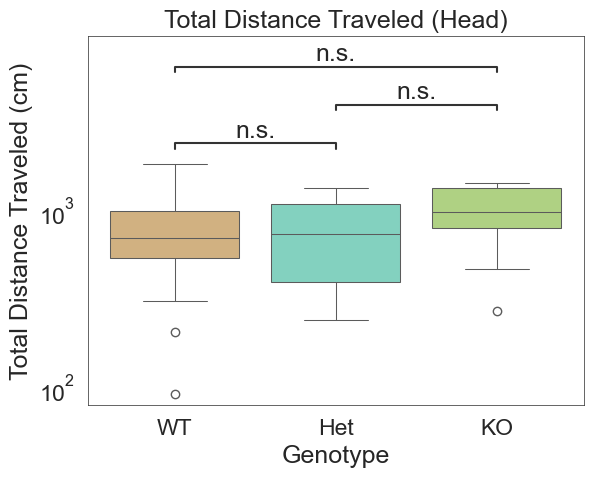

In [73]:
part = "head_midpoint"
data = grouped_avgs.xs(part, level="bodypart").reset_index()
g = sns.boxplot(data=data, x="genotype", y="total_distance", hue="genotype", order=genotype_order, palette=color_map, log_scale=True, linewidth=0.75)

annotator = Annotator(g, [("WT", "Het"), ("Het", "KO"), ("WT", "KO")], data=data, x="genotype", y="total_distance")
annotator.configure(test="t-test_ind", pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"], [1, "n.s."]], text_format="star", loc="inside")
annotator.apply_and_annotate()

g.set_title(f"Total Distance Traveled ({part_map[part]})")
g.set_xlabel("Genotype")
g.set_ylabel("Total Distance Traveled (cm)")
plt.savefig(f'{plot_export_location}/total_distance/totaldist_box_genotype_grouped_{part}.svg', format='svg')

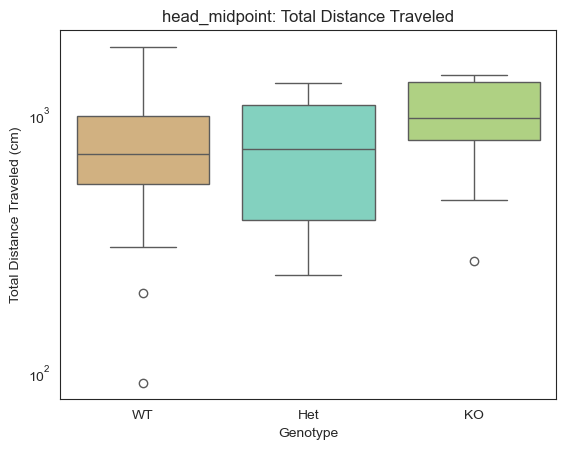

In [142]:
part = "head_midpoint"
data = grouped_avgs.xs(part, level="bodypart")
ax = sns.boxplot(data=data, x="genotype", y="total_distance", hue="genotype", order=genotype_order, palette=color_map, log_scale=True)

# ax = sns.catplot(data=grouped_avgs.xs(part, level="bodypart"), x="genotype", y="total_distance", 
#                  kind="box", errorbar="sd", palette=color_map, order=genotype_order)
ax.set_title(f"{part}: Total Distance Traveled")
ax.set_xlabel("Genotype")
ax.set_ylabel("Total Distance Traveled (cm)")
plt.savefig(f'{plot_export_location}/totaldist_box_genotype_grouped_{part}.svg', format='svg')

### Maternal Genotype

p-value annotation legend:
    n.s.: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Het vs. WT: t-test independent samples, P_val:4.770e-01 t=-7.178e-01


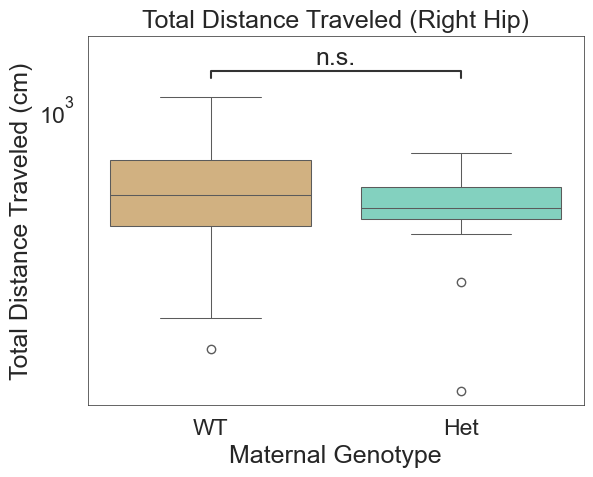

In [81]:
part = "right_hip"
data = grouped_avgs.xs(part, level="bodypart").reset_index()
g = sns.boxplot(data=data, x="maternal_genotype", y="total_distance", hue="maternal_genotype", order=["WT", "Het"], palette=color_map, log_scale=True, linewidth=0.75)

annotator = Annotator(g, [("WT", "Het")], data=data, x="maternal_genotype", y="total_distance")
annotator.configure(test="t-test_ind", pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"], [1, "n.s."]], text_format="star", loc="inside")
annotator.apply_and_annotate()

g.set_title(f"Total Distance Traveled ({part_map[part]})")
g.set_xlabel("Maternal Genotype")
g.set_ylabel("Total Distance Traveled (cm)")
plt.savefig(f'{plot_export_location}/total_distance/totaldist_box_maternal_genotype_grouped_{part}.svg', format='svg')

### Sex and Genotype

p-value annotation legend:
    n.s.: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Het vs. WT: t-test independent samples, P_val:2.397e-02 t=-2.345e+00


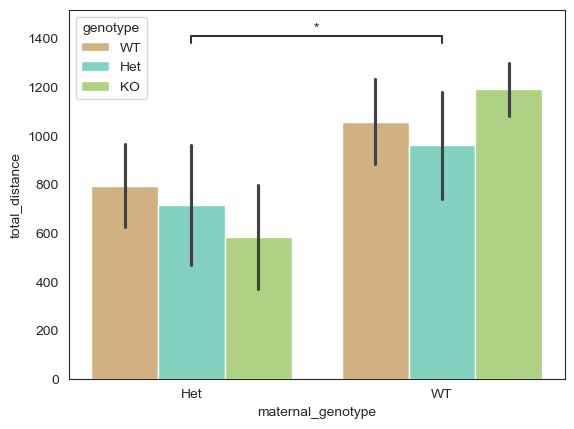

In [24]:
part = "nose"
ax = sns.barplot(data=grouped_avgs.xs(part, level="bodypart").reset_index(), x="maternal_genotype", y="total_distance", hue="genotype", palette=color_map, order=['Het', 'WT'], 
                 hue_order=genotype_order, errorbar="se")

annotator = Annotator(ax, [("Het", "WT")], data=grouped_avgs.xs(part, level="bodypart").reset_index(), x="maternal_genotype", y="total_distance")
annotator.configure(test="t-test_ind", pvalue_thresholds=[[1e-4, "****"], [1e-3, "***"], [1e-2, "**"], [0.05, "*"], [1, "n.s."]], text_format="star", loc="inside")
annotator.apply_and_annotate()

# ax.fig.suptitle(f"{part}: Total Distance Traveled")
# ax.set_axis_labels("Maternal Genotype", "Total Distance Traveled (cm)")
plt.show()
# plt.savefig(f'{plot_export_location}/total_distance_{part}_interaction.svg', format='svg')

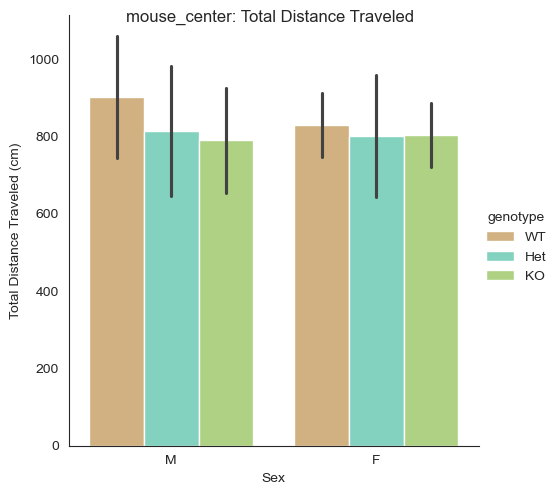

In [52]:
part = "mouse_center"
ax = sns.catplot(data=grouped_avgs.xs(part, level="bodypart"), x="sex", y="total_distance", hue="genotype", kind="bar", palette=color_map, order=['M', 'F'], 
                 hue_order=genotype_order, errorbar="se")
ax.fig.suptitle(f"{part}: Total Distance Traveled")
ax.set_axis_labels("Sex", "Total Distance Traveled (cm)")
plt.show()

### Distributions

In [20]:
counts_by_group = total_dist_df.xs("nose", level="bodypart").groupby(['maternal_genotype']).size()
print("Counts using size():")
print(counts_by_group)

Counts using size():
maternal_genotype
Het    27
WT     54
dtype: int64
